# 让Model花式吐token

## 上一节中我们已经实现了一个简单的可以自回归生成的Model类

依然存在可以优化的点：

1、现在我们就直接拿最大值的index当作下一个token的index，那有没有一种可能就是，这个只是局部最优不是全局最优呢？或者说我就单纯看这个不爽，我不想每次都取最大值。

2、我们现在支持的输入token都是一样长的，但是实际情况里句子肯定有长有短的，这要怎么办呢？

这一节解决问题1

In [1]:
# 现在的Model长这样
import torch
class Attention(torch.nn.Module):
    def __init__(self, dims):
        super().__init__()
        self.d_k = torch.tensor(dims)
        
        self.q_proj = torch.nn.Linear(self.d_k, self.d_k)
        self.k_proj = torch.nn.Linear(self.d_k, self.d_k)
        self.v_proj = torch.nn.Linear(self.d_k, self.d_k)

        self.k_cache = None
        self.v_cache = None
        
        self.feed_forward = torch.nn.Sequential(
            torch.nn.Linear(dims, 2*dims),
            torch.nn.ReLU(),
            torch.nn.Linear(2*dims, dims)
        )

        self.norm = torch.nn.LayerNorm(dims)

    def forward(self, x):
        res = x
        Q = self.q_proj(x)
        if self.k_cache is None and self.v_cache is None:
            self.k_cache = self.k_proj(x)
            self.v_cache = self.v_proj(x)
        else:
            self.k_cache = torch.cat([self.k_cache, self.k_proj(x)], dim=1)
            self.v_cache = torch.cat([self.v_cache, self.v_proj(x)], dim=1)

        K = self.k_cache
        V = self.v_cache

        attention_weights = torch.einsum('bqd, bLd->bqL', Q, K)
        attention_weights = torch.softmax(attention_weights/torch.sqrt(self.d_k), dim=-1)
        output = torch.einsum("bqL, bLd->bqd", attention_weights, V)
        output = self.norm(output+res)

        res = output
        output = self.feed_forward(output)
        output = self.norm(output+res)
        
        return output

    def empty_kv_cache(self):
        self.k_cache = None
        self.v_cache = None

class MyModel(torch.nn.Module):
    def __init__(self, vocabulary_size=9, dims=16):
        super().__init__()
        self.vocabulary_size=vocabulary_size
        self.dims = dims
        
        self.vocabulary = torch.nn.Embedding(self.vocabulary_size, self.dims)

        # 搞个两层的，之所以用ModuleList不用ModuleSequantial是因为大大概率会在中间做一些处理
        self.layers = torch.nn.ModuleList(
            [Attention(dims=self.dims) for _ in range(2)]
        )

        #分类器就简单了，就是一个Linear+softmax就好了，btw，在***ForCasualLM里，分类器一般都叫做LM_Head
        self.lm_head = torch.nn.Linear(self.dims, self.vocabulary_size, bias=False)
    
    def empty_all_kv_cache(self):
        for layer in self.layers:
            layer.empty_kv_cache()

    def forward(self, input_ids):
        input_features = self.vocabulary(input_ids)

        hidden_states = input_features
        for layer in self.layers:
            hidden_states = layer(hidden_states)

        logits = torch.softmax(self.lm_head(hidden_states), dim=-1)

        return logits, hidden_states
    
    def generate(self, input_ids, max_length=10):
        new_token=0
        self.empty_all_kv_cache()
        
        output_ids = [input_ids,]

        while new_token<max_length:
            logits = self.forward(input_ids=input_ids)[0]

            # 解决问题1就是要在这里搞，寻思下一个input_ids怎么换种方式搞出来
            probs = torch.softmax(logits, dim=-1)
            input_ids = probs.argmax(dim=-1)
            input_ids = input_ids[:, -1].reshape(-1, 1)
            
            output_ids.append(input_ids)
            new_token+=1

        output_ids = torch.cat(output_ids, dim=-1)
        return output_ids

## 思考解决办法

虽然我们可能不是想要概率最大的，但是吧他概率大也有大的道理，不能因为我们不想要最大的就去要最小的了那不合理。

ok按照这个思路来看，我们设定只要概率最大的前几个token，

是不是非常合理

In [2]:
class TestMyModel(MyModel):
    # 以防后续逻辑复杂，我们直接包装成一个函数
    def sample(self, logits, top_k):
        pass

    def generate(self, input_ids, max_length=10):
        new_token=0
        self.empty_all_kv_cache()
        
        output_ids = [input_ids,]

        while new_token<max_length:
            logits, _ = self.forward(input_ids=input_ids)
            
            # 改成这样，看得出来这个函数就是从logits里选出来input_ids
            input_ids = self.sample(logits=logits, top_k=3)
            
            output_ids.append(input_ids)
            new_token+=1

        output_ids = torch.cat(output_ids, dim=-1)
        return output_ids

In [3]:
# 想想这个sample的逻辑，输入的logits的shape是(batch_size, seq_len, voc_size)，输出的index是(batch_size, 1)
rand_logits = torch.randn(2, 3, 9)

# 只取最后一个token的，现在shape是(2,9)
rand_logits = rand_logits[:, -1, :]

# torch自带的函数，v的shape是(2, 3)，是从大到小的top-3。
# 为什么取top3？当然爱取什么取什么，but zju is top3。
v, index = torch.topk(rand_logits, 3)

# 因为是从大到小，所以v[:, -1]就是top3里最小的那个，设定为-float('Inf')是为了softmax时变成0
rand_logits[rand_logits<v[:, [-1]]] = -float('Inf')

# 为什么是v[:, [-1]]不是v[:, -1]可以试验一下
# rand_logits[rand_logits<v[:, -1]] = -float('Inf')

In [4]:
# 现在rand_logtis长什么样子看一看
print(rand_logits)
print(f"shape: {rand_logits.shape}")
# softmax一下概率看看长什么样
probs = torch.softmax(rand_logits, dim=-1)
print(probs)
print(f"shape: {probs.shape}")
# 没骗你，变0了吧

tensor([[   -inf,    -inf,    -inf,  1.3068,  1.2959,  0.4715,    -inf,    -inf,
            -inf],
        [ 1.2925,    -inf, -0.3790,  0.4385,    -inf,    -inf,    -inf,    -inf,
            -inf]])
shape: torch.Size([2, 9])
tensor([[0.0000, 0.0000, 0.0000, 0.4127, 0.4083, 0.1790, 0.0000, 0.0000, 0.0000],
        [0.6197, 0.0000, 0.1165, 0.2638, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000]])
shape: torch.Size([2, 9])


In [5]:
# 神奇的操作来了，既然是概率，那这topk我不想让随机抽了，我就想按概率抽
# 举个简单的例子，我topk里有个0.99的，那我分剩下的k-1分0.01的概率给你们够意思了，凭啥跟你们均等概率抽

# 刚好torch有内置的函数，可以多运行一下，大概率每次都不一样，但是只会是在topk的那几个里选
input_ids = torch.multinomial(probs, num_samples=1)
print(input_ids)

tensor([[5],
        [0]])


In [6]:
# 集合到类里
class TestMyModel(MyModel):
    def sample(self, logits, top_k):
        logits = logits[:, -1, :]
        v, _ = torch.topk(logits, top_k)

        logits[logits<v[:, [-1]]] = -float('Inf')
        probs = torch.softmax(logits, dim=-1)

        input_ids = torch.multinomial(probs, num_samples=1)
        return input_ids

    def generate(self, input_ids, max_length=10, top_k=3):
        new_token=0
        self.empty_all_kv_cache()
        
        output_ids = [input_ids,]

        while new_token<max_length:
            logits, _ = self.forward(input_ids=input_ids)
            
            # 改成这样，看得出来这个函数就是从logits里选出来input_ids
            input_ids = self.sample(logits=logits, top_k=top_k)
            
            output_ids.append(input_ids)
            new_token+=1

        output_ids = torch.cat(output_ids, dim=-1)
        return output_ids

In [7]:
# 测试一下
model = TestMyModel()
input_ids = torch.randint(0, 9, (2, 3))

print("测试一下top3的，看看三次生成的一不一样")
for index in range(3):
    print(f"第{index+1}次生成:")
    output_ids = model.generate(input_ids=input_ids,
                                top_k=3)
    print(output_ids)
print('¥'*50)
print("测试一下top1的，就相当于就是argmax了，看看三次生成的一不一样")
for index in range(3):
    print(f"第{index+1}次生成:")
    output_ids = model.generate(input_ids=input_ids,
                                top_k=1)
    print(output_ids)

测试一下top3的，看看三次生成的一不一样
第1次生成:
tensor([[0, 4, 4, 4, 4, 4, 2, 2, 0, 2, 2, 8, 1],
        [2, 7, 7, 0, 3, 8, 6, 6, 6, 2, 8, 8, 0]])
第2次生成:
tensor([[0, 4, 4, 8, 0, 2, 8, 6, 4, 0, 3, 4, 8],
        [2, 7, 7, 0, 5, 2, 0, 8, 6, 2, 8, 8, 0]])
第3次生成:
tensor([[0, 4, 4, 4, 2, 8, 0, 2, 0, 3, 6, 2, 2],
        [2, 7, 7, 8, 8, 6, 0, 8, 0, 3, 1, 1, 5]])
¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥
测试一下top1的，就相当于就是argmax了，看看三次生成的一不一样
第1次生成:
tensor([[0, 4, 4, 8, 0, 8, 0, 8, 0, 8, 0, 8, 0],
        [2, 7, 7, 6, 2, 5, 5, 5, 5, 5, 5, 5, 5]])
第2次生成:
tensor([[0, 4, 4, 8, 0, 8, 0, 8, 0, 8, 0, 8, 0],
        [2, 7, 7, 6, 2, 5, 5, 5, 5, 5, 5, 5, 5]])
第3次生成:
tensor([[0, 4, 4, 8, 0, 8, 0, 8, 0, 8, 0, 8, 0],
        [2, 7, 7, 6, 2, 5, 5, 5, 5, 5, 5, 5, 5]])


## top-k有了以后，想想可能还有什么问题？

Top-K 永远取固定的 $K$ 个。那

如果分布很集中（模型很确定），Top-K 可能会包含一些不相关的词，比如哪怕我某个token是0.999了，也有可能会有0.001的概率取其他的。

或者token1有0.5，token2有0.49，那么剩下的token也就没有必要看了。

那是不是可以说，我们只要把概率从大到小排列，累积前面的概率，只要超过了一定阈值那我们就把剩下的扔掉，一点机会也不给他们。

我们把这个概率叫做top-p。

In [8]:
# top5一下为了效果好看，但zju依然top3
rand_logits = torch.randn(2, 3, 9)
logits = rand_logits[:, -1, :]
v, index = torch.topk(logits, 5)
logits[logits<v[:, [-1]]] = -float('Inf')
# 看看现在logtis什么样
print(logits)

tensor([[-0.3575,  0.5462, -0.6171,  0.3252,    -inf,    -inf,    -inf,    -inf,
          1.2728],
        [ 0.1774,    -inf,  0.8236,    -inf,    -inf,  0.2331,    -inf, -0.3624,
          1.7368]])


In [9]:
# 假定我们舍弃掉概率0.9以外的token
top_p = 0.8

# 先把logtis从大到下排列一下
sorted_logits, sorted_indices = torch.sort(logits, descending=True)
# 先softmax一下得到概率，然后从index 0开始把概率做累积
probs = torch.softmax(sorted_logits, dim=-1)
cumulative_probs = torch.cumsum(probs, dim=-1)
print(f"累积前:{probs}")
print(f"累积后:{cumulative_probs}")

累积前:tensor([[0.4508, 0.2180, 0.1748, 0.0883, 0.0681, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5112, 0.2051, 0.1136, 0.1075, 0.0626, 0.0000, 0.0000, 0.0000, 0.0000]])
累积后:tensor([[0.4508, 0.6688, 0.8436, 0.9319, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
        [0.5112, 0.7162, 0.8299, 0.9374, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000]])


In [10]:
# 把超过top p的都选出来
sorted_indices_to_remove = cumulative_probs > top_p
print(sorted_indices_to_remove)

# 这一步的意思是刚超过的那个token也给保留，不用clone什么效果可以自己试一试。
sorted_indices_to_remove[..., 1:] = sorted_indices_to_remove[..., :-1].clone()
print(sorted_indices_to_remove)

tensor([[False, False,  True,  True,  True,  True,  True,  True,  True],
        [False, False,  True,  True,  True,  True,  True,  True,  True]])
tensor([[False, False, False,  True,  True,  True,  True,  True,  True],
        [False, False, False,  True,  True,  True,  True,  True,  True]])


In [11]:
for index in range(logits.shape[0]):
    # 生成一个需要扔掉的index序列
    indices_to_remove = sorted_indices[index][sorted_indices_to_remove[index]]
    # 这个序列的index都给-inf了
    print(f'改之前:{logits[index]}')
    logits[index, indices_to_remove] = -float('inf')
    print(f"改之后:{logits[index]}")
    print('¥'*50)

# 然后就可以正常和top_k一样的操作了
probs = torch.softmax(logits, dim=-1)
index_ids = torch.multinomial(probs, num_samples=1)

改之前:tensor([-0.3575,  0.5462, -0.6171,  0.3252,    -inf,    -inf,    -inf,    -inf,
         1.2728])
改之后:tensor([  -inf, 0.5462,   -inf, 0.3252,   -inf,   -inf,   -inf,   -inf, 1.2728])
¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥
改之前:tensor([ 0.1774,    -inf,  0.8236,    -inf,    -inf,  0.2331,    -inf, -0.3624,
         1.7368])
改之后:tensor([  -inf,   -inf, 0.8236,   -inf,   -inf, 0.2331,   -inf,   -inf, 1.7368])
¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥¥


In [12]:
# 把top-p 也集成一下到我们的Model类里
class TestMyModel(MyModel):
    def sample(self, logits, top_k, top_p):
        logits = logits[:, -1, :]

        # top-k部分
        if top_k>0:
            v, _ = torch.topk(logits, top_k)
            logits[logits<v[:, [-1]]] = -float('Inf')

        # top-p部分
        if top_p<1:
            sorted_logits, sorted_indices = torch.sort(logits, descending=True)
            temp_probs = torch.softmax(sorted_logits, dim=-1)
            cumulative_probs = torch.cumsum(temp_probs, dim=-1)

            sorted_indices_to_remove = cumulative_probs > top_p
            sorted_indices_to_remove[..., 1:] = sorted_indices_to_remove[..., :-1].clone()

            for index in range(logits.shape[0]):
                indices_to_remove = sorted_indices[index][sorted_indices_to_remove[index]]
                logits[index, indices_to_remove] = -float('inf')

        probs = torch.softmax(logits, dim=-1)
        input_ids = torch.multinomial(probs, num_samples=1)
        return input_ids

    def generate(self, input_ids, max_length=10, top_k=3, top_p=0.9):
        new_token=0
        self.empty_all_kv_cache()
        
        output_ids = [input_ids,]

        while new_token<max_length:
            logits, _ = self.forward(input_ids=input_ids)
            
            input_ids = self.sample(logits=logits, top_k=top_k, top_p=top_p)
            
            output_ids.append(input_ids)
            new_token+=1

        output_ids = torch.cat(output_ids, dim=-1)
        return output_ids

## top-k top-p都有了那还有什么问题？

不知道有没有发现，在上面写top-p逻辑的时候经常会出现各个token差异不大的情况。

这其实不是我们想要的，我们最终最终肯定还是希望每次生成最大概率的前几个token就是我们想要的token

（谁闲得没事寻思后面的token其实是更好的token

那有没有什么合理的办法能够简单改一改logtis从而改prob？

In [13]:
from matplotlib import pyplot as plt
# 生成100个独立同分布的，mean是0，std是0.01的logits，然后从大到小排列
logits = torch.randn(100)/10
logits, _ = torch.sort(logits, descending=True)

probs1 = torch.softmax(logits, dim=-1)
probs2 = torch.softmax(logits/5, dim=-1)
probs3 = torch.softmax(logits/0.2, dim=-1)

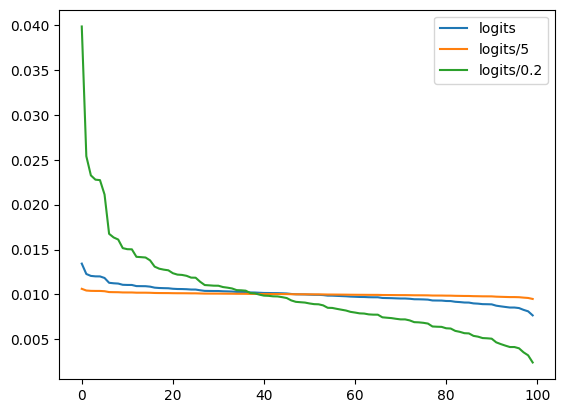

In [14]:
plt.plot(probs1, label='logits')
plt.plot(probs2, label='logits/5')
plt.plot(probs3, label='logits/0.2')
plt.legend()

发现了，想要probs分布变得尖锐，可以让logtis除以一个小于1的数

我们把这个数字叫做temperture（滑稽

为什么？因为描述热运动就是用的T，T越大热运动越均匀，直接copy过来

In [15]:
# 把temperture也集成进来
class TestMyModel(MyModel):
    def sample(self, logits, top_k, top_p, temperture):
        # 直接应用进来
        logits = logits[:, -1, :]/temperture

        if top_k>0:
            v, _ = torch.topk(logits, top_k)
            logits[logits<v[:, [-1]]] = -float('Inf')

        if top_p<1:
            sorted_logits, sorted_indices = torch.sort(logits, descending=True)
            temp_probs = torch.softmax(sorted_logits, dim=-1)
            cumulative_probs = torch.cumsum(temp_probs, dim=-1)

            sorted_indices_to_remove = cumulative_probs > top_p
            sorted_indices_to_remove[..., 1:] = sorted_indices_to_remove[..., :-1].clone()

            for index in range(logits.shape[0]):
                indices_to_remove = sorted_indices[index][sorted_indices_to_remove[index]]
                logits[index, indices_to_remove] = -float('inf')

        probs = torch.softmax(logits, dim=-1)
        input_ids = torch.multinomial(probs, num_samples=1)
        return input_ids

    def generate(self, input_ids, max_length=10, top_k=3, top_p=0.9, temperture=1.0):
        new_token=0
        self.empty_all_kv_cache()
        
        output_ids = [input_ids,]

        while new_token<max_length:
            logits, _ = self.forward(input_ids=input_ids)
            
            input_ids = self.sample(logits=logits, top_k=top_k, top_p=top_p, temperture=temperture)
            
            output_ids.append(input_ids)
            new_token+=1

        output_ids = torch.cat(output_ids, dim=-1)
        return output_ids

## 至此我们就让我们的Model变得非常哇塞了

现在这个model就在接受到一个input_ids后，根据需求不同就可以灵活生成output_ids了

之后再把输出的output_ids给解码回正常的自然语言这就是用户最终见到的样子了。